# Lung Segmentation Model 1 - Tuning

From https://www.nature.com/articles/s41598-022-12743-y Liu, W., Luo, J., Yang, Y. et al. Automatic lung segmentation in chest X-ray images using improved U-Net. Sci Rep 12, 8649 (2022). https://doi.org/10.1038/s41598-022-12743-y
and the github repository : https://github.com/2112942597/2985/blob/main/ab/model.py#L47


As we work on Kaggle, this notebook has 2 parts: 
- a common part where we generat the masked CLAHE images datasets,
- a specific part where we perform the model tuning to determine the optimal hyperparameters.

## Common part: setting up the Working Environment and creating datasets

### Imports



In [1]:
import torch
import torch.nn as nn
import platform
import psutil
import os
import shutil

# Related third party imports
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from sklearn import metrics
from tqdm import tqdm

import torchvision.transforms.functional
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image


### Working Evironment

#### List physical devices

In [2]:
# List physical devices
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"Number of GPUs: {num_gpus}")
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        gpu_capability = torch.cuda.get_device_capability(i)
        print(f"\nGPU {i} details:")
        print(f"Name: {gpu_name}")
        print(f"Capability: {gpu_capability}")
else:
    print("No GPU available")

# Get CPU information
cpu_info = platform.processor()
print("\nCPU details:", cpu_info)

# Get more detailed CPU information using psutil
cpu_freq = psutil.cpu_freq()
cpu_count = psutil.cpu_count(logical=False)
cpu_count_logical = psutil.cpu_count(logical=True)
cpu_stats = psutil.cpu_stats()
cpu_times = psutil.cpu_times()

print("\nDetailed CPU information:")
print(f"Physical cores: {cpu_count}")
print(f"Total cores: {cpu_count_logical}")
print(f"Max Frequency: {cpu_freq.max:.2f}Mhz")
print(f"Min Frequency: {cpu_freq.min:.2f}Mhz")
print(f"Current Frequency: {cpu_freq.current:.2f}Mhz")

No GPU available

CPU details: AMD64 Family 25 Model 80 Stepping 0, AuthenticAMD

Detailed CPU information:
Physical cores: 8
Total cores: 16
Max Frequency: 2000.00Mhz
Min Frequency: 0.00Mhz
Current Frequency: 2000.00Mhz


### Variables & Paths

In [3]:
def set_paths():
    """
    Sets the dataset and working paths based on the environment (Kaggle or local).
    Returns:
        dataset_path (str): The path to the dataset directory.
        working_path (str): The path to the working directory.
    """
    # Check if running on Kaggle
    if os.path.exists('/kaggle'):
        print("Running on Kaggle")
        dataset_path = '/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data'
        working_path = '/kaggle/working/COVID-EX-Qu-dataset'
    else:
        print("Running on local")
        # Local paths from the notebooks folder
        notebook_dir = os.path.abspath(".")
        print("dossier notebooks :", notebook_dir)

        relative_raw_data_path = os.path.join("..", "data", "raw", "Lung Segmentation Data", "Lung Segmentation Data")
        dataset_path = os.path.abspath(relative_raw_data_path)
        print("dossier data/raw :", dataset_path)

        relative_workingdata_path = os.path.join("..", "data", "working")
        working_path = os.path.abspath(relative_workingdata_path)

    # Validate paths
    if not os.path.exists(dataset_path):
        raise FileNotFoundError(f"The dataset path does not exist: {dataset_path}")
    if not os.path.exists(working_path):
        raise FileNotFoundError(f"The working path does not exist: {working_path}")

    return dataset_path, working_path

In [4]:
GROUPS = ['COVID-19', 'Normal', 'Non-COVID']
SETS = ['Val', 'Test', 'Train']
BATCH_SIZE = 32

# Paths
DATASET_PATH, WORKING_PATH = set_paths()

print(f"DATASET_PATH: {DATASET_PATH}")
print(f"WORKING_PATH: {WORKING_PATH}")

Running on local
dossier notebooks : c:\Users\Florent\Documents\data_science\ds-covid-radio-dl\notebooks
dossier data/raw : c:\Users\Florent\Documents\data_science\ds-covid-radio-dl\data\raw\Lung Segmentation Data\Lung Segmentation Data
DATASET_PATH: c:\Users\Florent\Documents\data_science\ds-covid-radio-dl\data\raw\Lung Segmentation Data\Lung Segmentation Data
WORKING_PATH: c:\Users\Florent\Documents\data_science\ds-covid-radio-dl\data\working


### Copy of the data structure  

Copy of the 3 (train, valm, test) sets from the Kaggle dataset to: data/working/model.

data/  
├── working/  
│   ├── train/  
│   │   ├── COVID-19/  
│   │   │   ├── images/  
│   │   │   └── masks/  
│   │   ├── Non-COVID/  
│   │   │   ├── images/  
│   │   │   └── masks/  
│   │   └── Normal/  
│   │       ├── images/  
│   │       └── masks/  
│   ├── val/  


In [5]:
def copy_directory(src: str, dst: str, replace_existing: bool = False) -> None:
    """
    Copy the contents of a source directory to a destination directory, 
    with an option to replace existing files or only copy files that do not already exist.
    Displays a progress bar for the copy operation.

    Parameters:
    src (str): The path of the source directory.
    dst (str): The path of the destination directory.
    replace_existing (bool): If True, replace existing files in the destination directory.
                             If False, only copy files that do not already exist. Default is False.

    Returns:
    None
    """
    if not os.path.exists(dst):
        os.makedirs(dst)
    
    # Collect all files to be copied
    files_to_copy = []
    for root, dirs, files in os.walk(src):
        for file in files:
            files_to_copy.append((root, file))
    
    # Initialize the progress bar
    with tqdm(total=len(files_to_copy), desc="Copying files", unit="file") as pbar:
        for root, file in files_to_copy:
            relative_path = os.path.relpath(root, src)
            dest_dir = os.path.join(dst, relative_path)
            
            if not os.path.exists(dest_dir):
                os.makedirs(dest_dir)
            
            src_file = os.path.join(root, file)
            dest_file = os.path.join(dest_dir, file)
            
            if replace_existing or not os.path.exists(dest_file):
                shutil.copy2(src_file, dest_file)
                pbar.set_postfix(file=file)
            pbar.update(1)

In [6]:
copy_directory(src=DATASET_PATH, dst=WORKING_PATH, replace_existing=False)

Copying files: 100%|██████████| 67840/67840 [00:05<00:00, 12312.78file/s]


In [7]:
def check_data_integrity(src, dst, sets, groups, ref_covid, ref_noncovid, ref_normal):
    """
    Checks the integrity of data by counting the number of images in each category
    and comparing them to reference values. Displays three random images from each set and group in grayscale.
    Also compares the number of files for each set and group between src and dst.

    Parameters:
    - src: str
        The directory where source image data is stored.
    - dst: str
        The directory where image data has been copied.
    - sets: list
        A list of sets, e.g., ['Val', 'Test', 'Train'].
    - groups: list
        A list of groups, e.g., ['COVID-19', 'Normal', 'Non-COVID'].
    - ref_covid: int
        Reference number of COVID-19 images.
    - ref_noncovid: int
        Reference number of Non-COVID images.
    - ref_normal: int
        Reference number of Normal images.

    Displays:
    - Three random images from each set and group in grayscale.
    
    Prints:
    - The number of images in each set and group.
    - The percentage of images found compared to the reference values.
    - The comparison of the number of files between src and dst.
    """
    n_covid = 0
    n_noncovid = 0
    n_normal = 0
    outputs = []

    for sett in sets:
        for group in groups:
            src_ima_dir = os.path.join(src, sett, group, 'images')
            dst_ima_dir = os.path.join(dst, sett, group, 'images')
            
            src_image_files = os.listdir(src_ima_dir)
            dst_image_files = os.listdir(dst_ima_dir)
            
            num_src_images = len(src_image_files)
            num_dst_images = len(dst_image_files)
            
            outputs.append(f"In the set {sett}, there are {num_src_images} source images and {num_dst_images} destination images of {group}")

            if num_dst_images > 0:
                # Randomly select 3 images to display, or fewer if there are less than 3.
                sample_images = random.sample(dst_image_files, min(3, num_dst_images))

                # Displaying the images using matplotlib
                fig, axes = plt.subplots(1, min(3, num_dst_images), figsize=(15, 5))
                for idx, img_name in enumerate(sample_images):
                    img_path = os.path.join(dst_ima_dir, img_name)
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    axes[idx].imshow(img, cmap='gray')
                    axes[idx].axis('off')
                    axes[idx].set_title(f"{group} ({sett})")
                plt.show()

            if group == "COVID-19":
                n_covid += num_dst_images
            elif group == "Non-COVID":
                n_noncovid += num_dst_images
            elif group == "Normal":
                n_normal += num_dst_images

    outputs.append(f"\nThere are {n_covid} COVID images found, {n_covid / ref_covid * 100:.2f}% of the original dataset from Kaggle.")
    outputs.append(f"There are {n_noncovid} non-COVID images, {n_noncovid / ref_noncovid * 100:.2f}% of the original dataset from Kaggle.")
    outputs.append(f"There are {n_normal} normal images, {n_normal / ref_normal * 100:.2f}% of the original dataset from Kaggle.")

    for output in outputs:
        print(output)

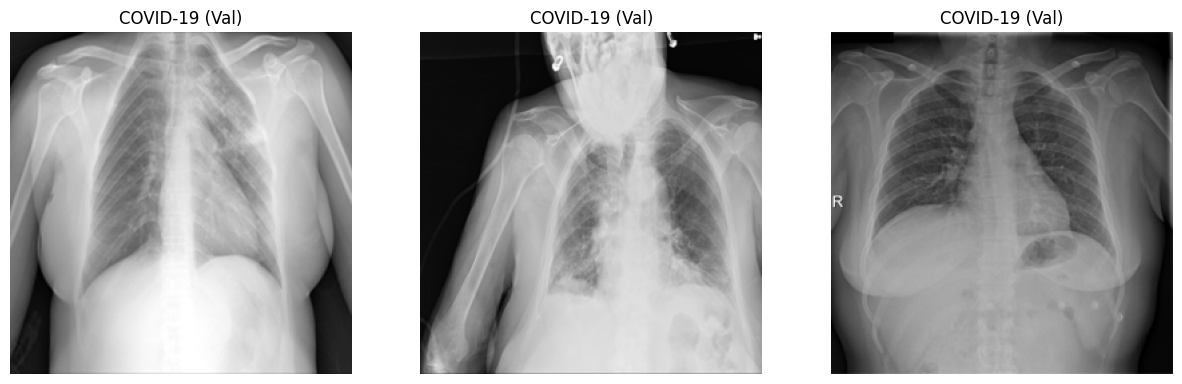

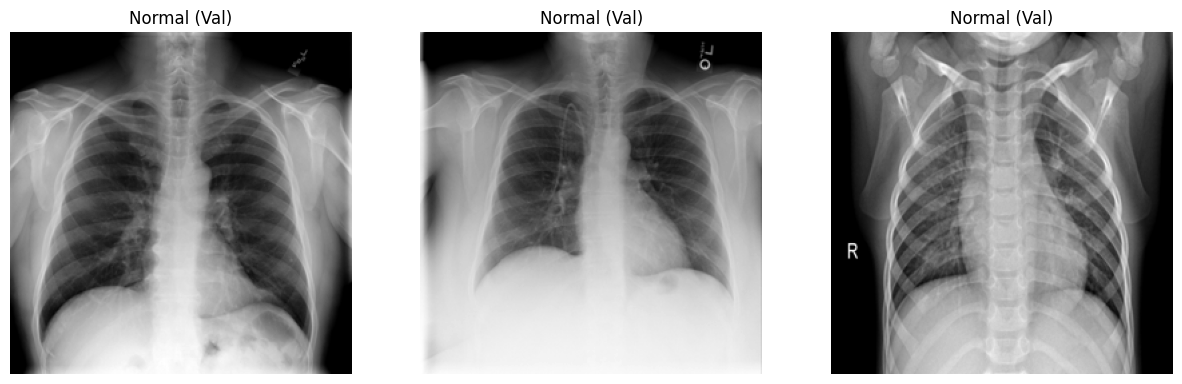

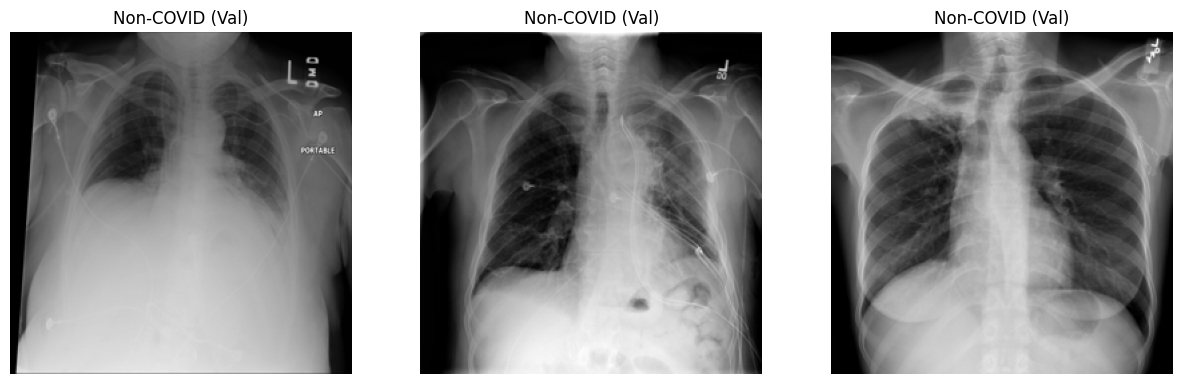

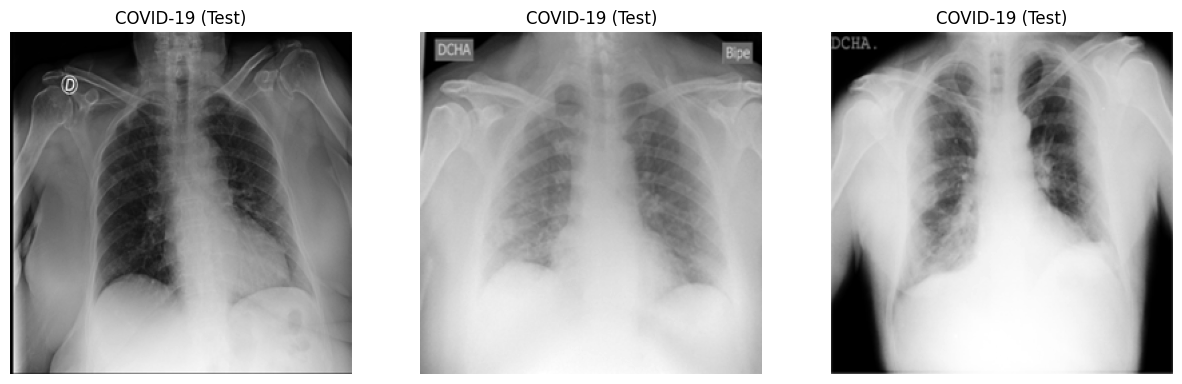

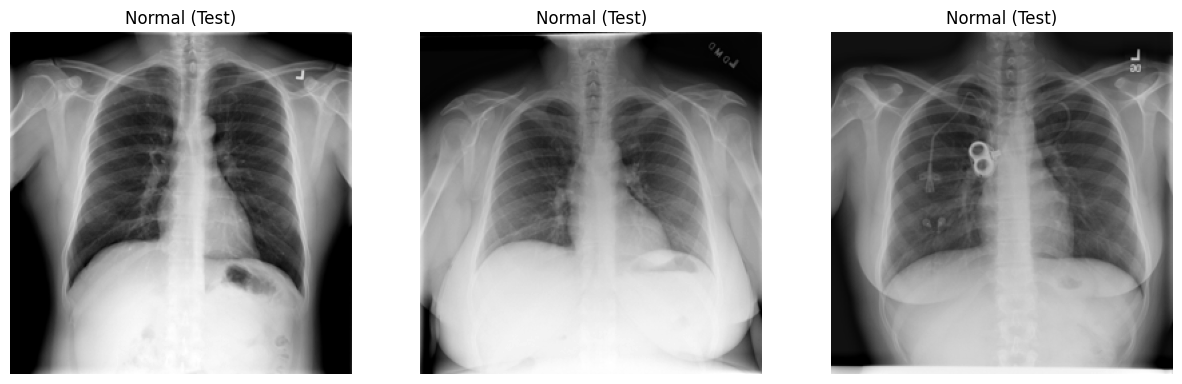

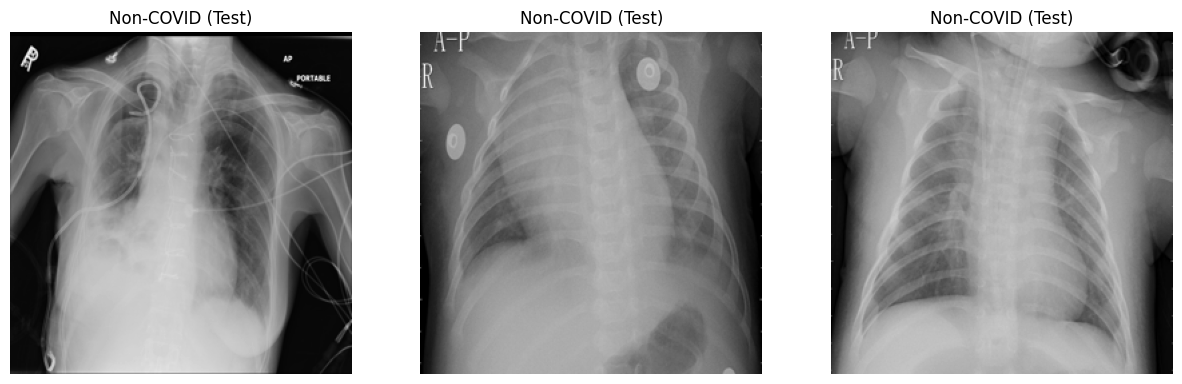

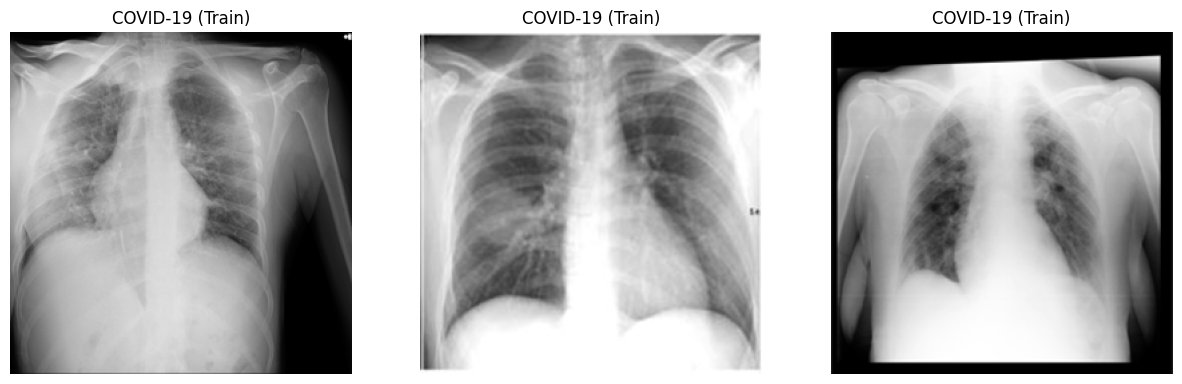

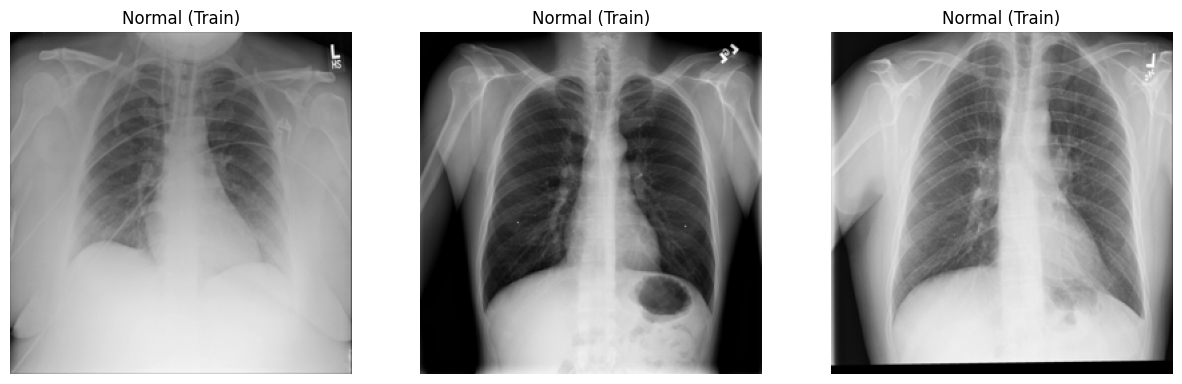

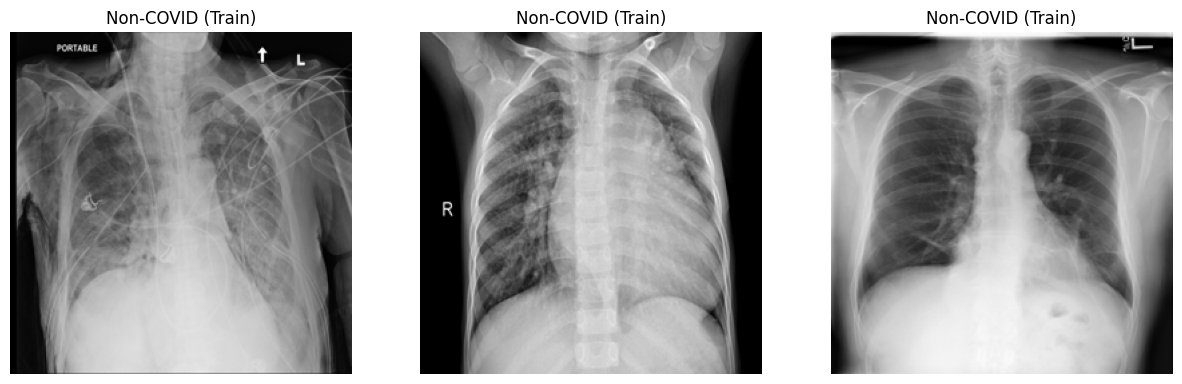

In the set Val, there are 1903 source images and 1903 destination images of COVID-19
In the set Val, there are 1712 source images and 1712 destination images of Normal
In the set Val, there are 1802 source images and 1802 destination images of Non-COVID
In the set Test, there are 2395 source images and 2395 destination images of COVID-19
In the set Test, there are 2140 source images and 2140 destination images of Normal
In the set Test, there are 2253 source images and 2253 destination images of Non-COVID
In the set Train, there are 7658 source images and 7658 destination images of COVID-19
In the set Train, there are 6849 source images and 6849 destination images of Normal
In the set Train, there are 7208 source images and 7208 destination images of Non-COVID

There are 11956 COVID images found, 100.00% of the original dataset from Kaggle.
There are 11263 non-COVID images, 100.00% of the original dataset from Kaggle.
There are 10701 normal images, 100.00% of the original dataset from 

In [8]:
check_data_integrity(
    src=DATASET_PATH, 
    dst=WORKING_PATH, 
    sets=SETS, 
    groups=GROUPS, 
    ref_covid=11956, 
    ref_noncovid=11263, 
    ref_normal=10701
)

## Specific part: Lung Segmentation Model Tuning

### Dice coefficient and Dice loss 

Also called Sørensen–Dice coefficient, Dice coefficient is a similarity metric commonly used in image segmentation to measure the similarity between two sets. 


#### Backbone: EfficientNetB4
https://arxiv.org/abs/1905.11946

#### U-Net model

https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/  
https://arxiv.org/abs/1505.04597

https://github.com/Mostafa-wael/U-Net-in-PyTorch/blob/main/U_Net.ipynb

In [9]:
class DoubleConvolution(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        # First 3x3 convolutional layer
        self.first = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.act1 = nn.ReLU()
        # Second 3x3 convolutional layer
        self.second = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.act2 = nn.ReLU()

    def forward(self, x: torch.Tensor):
        # Apply the two convolution layers and activations
        x = self.first(x)
        x = self.act1(x)
        x = self.second(x)
        return self.act2(x)

In [10]:
class DownSample(nn.Module):
    def __init__(self):
        super().__init__()
        # Max pooling layer
        self.pool = nn.MaxPool2d(2)

    def forward(self, x: torch.Tensor):
        return self.pool(x)

In [11]:
class UpSample(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        # Up-convolution
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x: torch.Tensor):
        return self.up(x)

In [12]:
class CropAndConcat(nn.Module):
    def forward(self, x: torch.Tensor, contracting_x: torch.Tensor):
        # Crop the feature map from the contracting path to the size of the current feature map
        contracting_x = torchvision.transforms.functional.center_crop(contracting_x, [x.shape[2], x.shape[3]])
        # Concatenate the feature maps
        x = torch.cat([x, contracting_x], dim=1)
        return x

In [13]:
class UNet(nn.Module):
    def __init__(self, out_channels: int):

        super().__init__()
        # Double convolution layers for the contracting path.
        # The number of features gets doubled at each step starting from 64.
        down_conv_sizes = [(3, 64), (64, 128), (128, 256), (256, 512)]
        self.down_conv = nn.ModuleList([DoubleConvolution(i, o) for i, o in down_conv_sizes])
        
        # Down sampling layers for the contracting path
        self.down_sample = nn.ModuleList([DownSample() for _ in range(4)])

        # The two convolution layers at the lowest resolution (the bottom of the U).
        self.middle_conv = DoubleConvolution(512, 1024)

        # Up sampling layers for the expansive path.
        # The number of features is halved with up-sampling.
        upsample_sizes = [(1024, 512), (512, 256), (256, 128), (128, 64)]
        
        self.up_sample = nn.ModuleList([UpSample(i, o) for i, o in upsample_sizes])
        # Double convolution layers for the expansive path.
        # Their input is the concatenation of the current feature map and the feature map from the
        # contracting path. Therefore, the number of input features is double the number of features
        # from up-sampling.
        up_conv_sizes = [(1024, 512), (512, 256), (256, 128), (128, 64)]
        self.up_conv = nn.ModuleList([DoubleConvolution(i, o) for i, o in up_conv_sizes])
        
        # Crop and concatenate layers for the expansive path.
        self.concat = nn.ModuleList([CropAndConcat() for _ in range(4)])
        
        # Final 1x1 convolution layer to produce the output
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor):
        # To collect the outputs of contracting path for later concatenation with the expansive path.
        pass_through = []
        # Contracting path
        for i in range(len(self.down_conv)):
            # Two 3x3 convolutional layers
            x = self.down_conv[i](x)
            # Collect the output
            pass_through.append(x)
            # Down-sample
            x = self.down_sample[i](x)

        # Two 3x3 convolutional layers at the bottom of the U-Net
        x = self.middle_conv(x)

        # Expansive path
        for i in range(len(self.up_conv)):
            # Up-sample
            x = self.up_sample[i](x)
            # Concatenate the output of the contracting path
            x = self.concat[i](x, pass_through.pop())
            # Two 3x3 convolutional layers
            x = self.up_conv[i](x)

        # Final 1x1 convolution layer
        out = self.final_conv(x)

        return out

#### Data generator

In [14]:
class COVIDDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.mask_paths = []

        # Walk through the directory structure and collect image and mask paths
        for category in ['COVID-19', 'Non-COVID', 'Normal']:
            image_dir = os.path.join(root_dir, category, 'images')
            mask_dir = os.path.join(root_dir, category, 'lung masks')
            for image_name in os.listdir(image_dir):
                self.image_paths.append(os.path.join(image_dir, image_name))
                self.mask_paths.append(os.path.join(mask_dir, image_name))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        image = Image.open(image_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask


In [15]:
# Data transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

In [16]:
train_dataset = COVIDDataset(root_dir=os.path.join(WORKING_PATH, 'Train'), transform=transform)
val_dataset = COVIDDataset(root_dir=os.path.join(WORKING_PATH, 'Val'), transform=transform)
test_dataset = COVIDDataset(root_dir=os.path.join(WORKING_PATH, 'Test'), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4)

In [18]:
# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(out_channels=1).to(device)

In [19]:
# Loss function and optimizer
# Use Binary Cross Entropy for binary segmentation task (adjust for your task)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
# Training loop
num_epochs = 1

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device).float()  # Convert masks to float tensor for BCE loss

        masks = masks.squeeze(1) # revoir ou la dimension supplémentaire est introduite : dans la transformation ? 

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, masks.unsqueeze(1))  # Add channel dimension to masks

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')

    # Validation loop
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0
    with torch.no_grad():  # No need to compute gradients during validation
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device).float()

            outputs = model(images)
            loss = criterion(outputs, masks.unsqueeze(1))

            val_loss += loss.item() * images.size(0)

    val_loss /= len(val_loader.dataset)
    print(f'Validation Loss: {val_loss:.4f}')


# Save the trained model
torch.save(model.state_dict(), 'unet_covid19.pth')


In [ ]:
# les 2 blocks residuels provoquent un pb de coherence de shapes
# mettre dice en metrique
# keras tuner pour perf unet de base
# tester de mettre l'efficient net dans l'encoder 
# et d'ajouter les blocks residuels etc. dans le decoder

In [ ]:
# Save the model weights
# model.save_weights('unet.weights.h5')

In [ ]:
# erreur dans l'écriture du bloc résiduel : le faire passer dans le bloc convolution de l'encoder

